In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Environment initialized successfully.")

Environment initialized successfully.


In [8]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
DATA_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 7,043
Columns: 21


In [10]:
df.shape

(7043, 21)

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Quality Assessment

Before performing exploratory analysis, we assess the dataset for missing values, invalid entries, duplicates, incorrect data types, and inconsistent categorical values.

In [14]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [15]:
df["TotalCharges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [16]:
df["TotalCharges"].astype(str).str.strip().value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
19.55     7
45.3      7
20.15     6
20.25     6
Name: count, dtype: int64

In [17]:
df["TotalCharges"].astype(str).str.strip().value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
19.55     7
45.3      7
20.15     6
20.25     6
Name: count, dtype: int64

In [18]:
blank_total_charges = df[
    df["TotalCharges"].astype(str).str.strip() == ""
]

blank_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [19]:
blank_total_charges[[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "Churn"
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [20]:
blank_total_charges["tenure"].describe()

count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64

In [21]:
df["customerID"].duplicated().sum()

np.int64(0)

In [22]:
df["customerID"].nunique()

7043

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- customerID ---
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

In [25]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 4.1 Overall Churn Distribution

The target variable is moderately imbalanced. Approximately three quarters of customers remain with the company, while roughly one quarter churn.

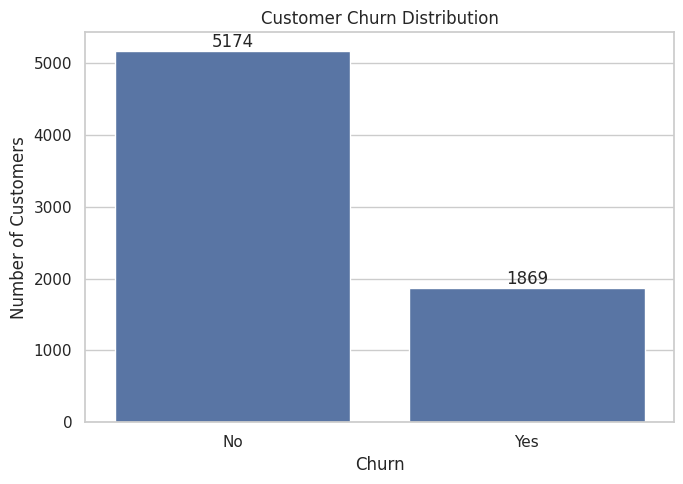

In [26]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

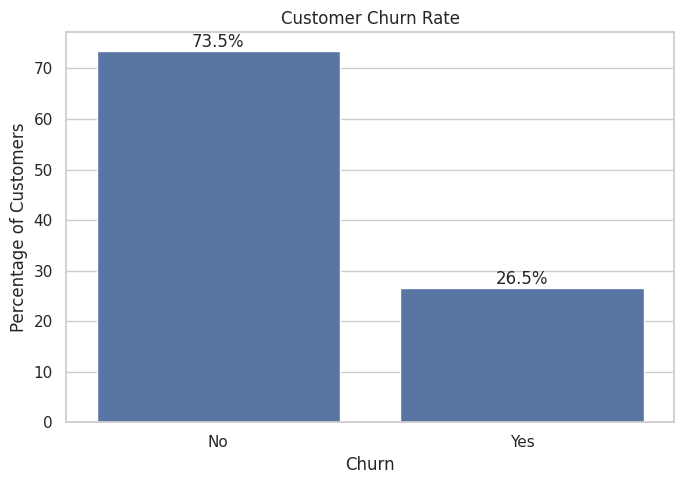

In [27]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=churn_percentage.index,
    y=churn_percentage.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [28]:
contract_churn_rate = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


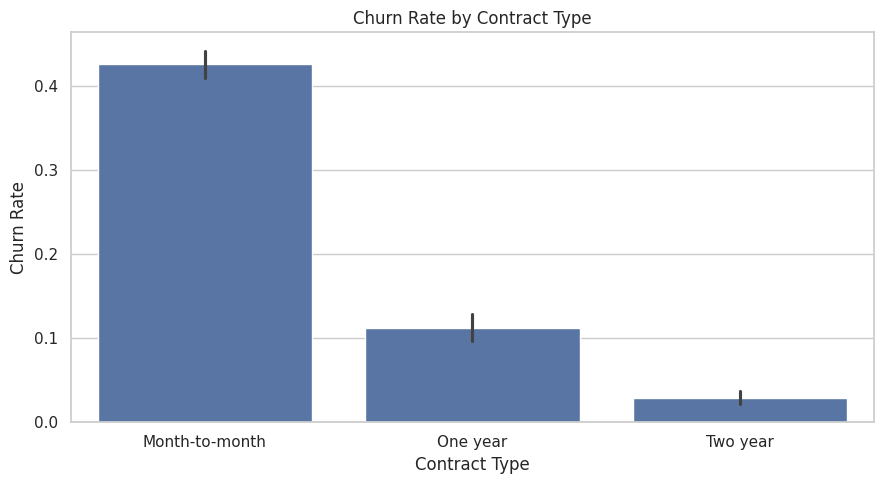

In [29]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df,
    x="Contract",
    y=df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

In [30]:
contract_churn_rate = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Business Insight

Contract type shows a strong relationship with customer churn. Customers on month-to-month contracts have a substantially higher churn rate (42.71%) compared with customers on one-year contracts (11.27%) and two-year contracts (2.83%).

This suggests that customers without long-term contractual commitments may represent a high-risk segment for customer retention.

However, this analysis shows association rather than causation. Additional customer and service characteristics will be investigated before drawing conclusions about the underlying drivers of churn.

In [31]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Business Insight

Customer tenure shows a strong association with churn. Customers who remained with the company had an average tenure of 37.57 months, compared with 17.98 months for customers who churned.

The median tenure was 38 months for retained customers and only 10 months for churned customers. Additionally, 25% of churned customers had a tenure of two months or less.

These results suggest that customers in the early stages of their relationship with the company may represent a particularly important retention segment.

However, tenure alone does not determine churn, as customers with long tenures can also churn. Therefore, tenure will be evaluated alongside contract type, pricing, services, and other customer characteristics during the modeling stage.

In [32]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Business Insight

Monthly charges show a noticeable association with customer churn. Customers who churned had an average monthly charge of €74.44, compared with €61.27 for customers who remained with the company. The median monthly charge was also higher among churned customers (€79.65 versus €64.43).

This suggests that customers with higher monthly charges may represent a higher-risk segment. However, monthly charges may be related to other factors such as internet service, contract type, and additional services. These relationships will be investigated before drawing conclusions about the underlying drivers of churn.

In [33]:
internet_churn_rate = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


### Business Insight

Internet service type shows a strong association with customer churn. Fiber optic customers have an observed churn rate of 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

The high churn rate among Fiber optic customers identifies this group as a potentially important retention segment. However, this relationship may be influenced by other variables such as contract type, tenure, and monthly charges. Further analysis is required before interpreting internet service as an independent driver of churn.

In [34]:
payment_churn_rate = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


### Business Insight

Payment method shows a strong association with customer churn. Customers using electronic checks have an observed churn rate of 45.29%, substantially higher than customers using automatic bank transfer (16.71%), automatic credit card payments (15.24%), or mailed checks (19.11%).

The substantially higher churn rate among electronic-check customers identifies this group as a potentially important retention segment. However, payment method may be correlated with other customer characteristics such as contract type, tenure, and service usage. Therefore, further multivariate analysis and machine learning will be used to determine the combined predictive value of these features.

In [35]:
contract_payment = pd.crosstab(
    df["Contract"],
    df["PaymentMethod"],
    normalize="index"
).mul(100).round(2)

contract_payment

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,15.20,14.01,47.74,23.05
One year,26.54,27.02,23.56,22.88
Two year,33.27,34.28,9.91,22.54


In [36]:
contract_payment_churn = (
    df.groupby(["Contract", "PaymentMethod"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="ChurnRate")
)

contract_payment_churn

,Contract,PaymentMethod,ChurnRate
0,Month-to-month,Bank transfer (automatic),34.13
1,Month-to-month,Credit card (automatic),32.78
2,Month-to-month,Electronic check,53.73
3,Month-to-month,Mailed check,31.58
4,One year,Bank transfer (automatic),9.72
5,One year,Credit card (automatic),10.30
6,One year,Electronic check,18.44
7,One year,Mailed check,6.82
8,Two year,Bank transfer (automatic),3.37
9,Two year,Credit card (automatic),2.24


### Business Insight — Contract and Payment Method Interaction

The combined analysis of contract type and payment method reveals that electronic-check customers have the highest observed churn rate within every contract category.

For month-to-month customers, the churn rate among electronic-check users is 53.73%, compared with 31.58%–34.13% for the other payment methods. The same pattern is observed for one-year and two-year contracts, although the overall churn rates are substantially lower for longer contracts.

This suggests that both contract type and payment method contain useful information for predicting churn. However, these relationships are observational and do not establish causality. Multivariate modeling will be used later to evaluate the combined predictive contribution of these variables.

In [37]:
tenure_bins = [0, 6, 12, 24, 48, 72]

tenure_labels = [
    "0–6 months",
    "7–12 months",
    "13–24 months",
    "25–48 months",
    "49–72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

tenure_churn_rate = (
    pd.crosstab(
        df["TenureGroup"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

tenure_churn_rate

Churn,No,Yes
TenureGroup,,
0–6 months,47.06,52.94
7–12 months,64.11,35.89
13–24 months,71.29,28.71
25–48 months,79.61,20.39
49–72 months,90.49,9.51


### Business Insight — Customer Lifecycle

Customer tenure shows a strong and consistent association with churn. Customers with 0–6 months of tenure have the highest observed churn rate at 52.94%. The churn rate decreases progressively across longer tenure groups, reaching 9.51% among customers with 49–72 months of tenure.

This indicates that the early customer lifecycle represents a particularly high-risk period for retention. From a business perspective, onboarding, early customer support, and proactive retention strategies may be especially valuable during the first several months of the customer relationship.

The analysis represents an observed association and does not establish that tenure itself causes churn. Other variables, including contract type, pricing, and services, may contribute to the relationship.

In [39]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [41]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [42]:
df[numeric_columns].corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [43]:
df.select_dtypes(include=["int64", "float64"])

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [45]:
df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [46]:
df[[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "ChurnBinary"
]].corr()

,SeniorCitizen,tenure,MonthlyCharges,ChurnBinary
SeniorCitizen,1.000000,0.016567,0.220173,0.150889
tenure,0.016567,1.000000,0.247900,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.193356
ChurnBinary,0.150889,-0.352229,0.193356,1.000000


In [47]:
categorical_features = [
    column for column in df.select_dtypes(include="object").columns
    if column not in ["customerID", "TotalCharges", "Churn"]
]

categorical_churn_summary = []

for column in categorical_features:
    churn_rates = (
        df.groupby(column, observed=True)["ChurnBinary"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )
    
    for category, rate in churn_rates.items():
        categorical_churn_summary.append({
            "Feature": column,
            "Category": category,
            "ChurnRate": round(rate, 2)
        })

categorical_churn_summary = pd.DataFrame(categorical_churn_summary)

categorical_churn_summary

,Feature,Category,ChurnRate
0,gender,Female,26.92
1,gender,Male,26.16
2,Partner,No,32.96
3,Partner,Yes,19.66
4,Dependents,No,31.28
5,Dependents,Yes,15.45
6,PhoneService,Yes,26.71
7,PhoneService,No,24.93
8,MultipleLines,Yes,28.61
9,MultipleLines,No,25.04


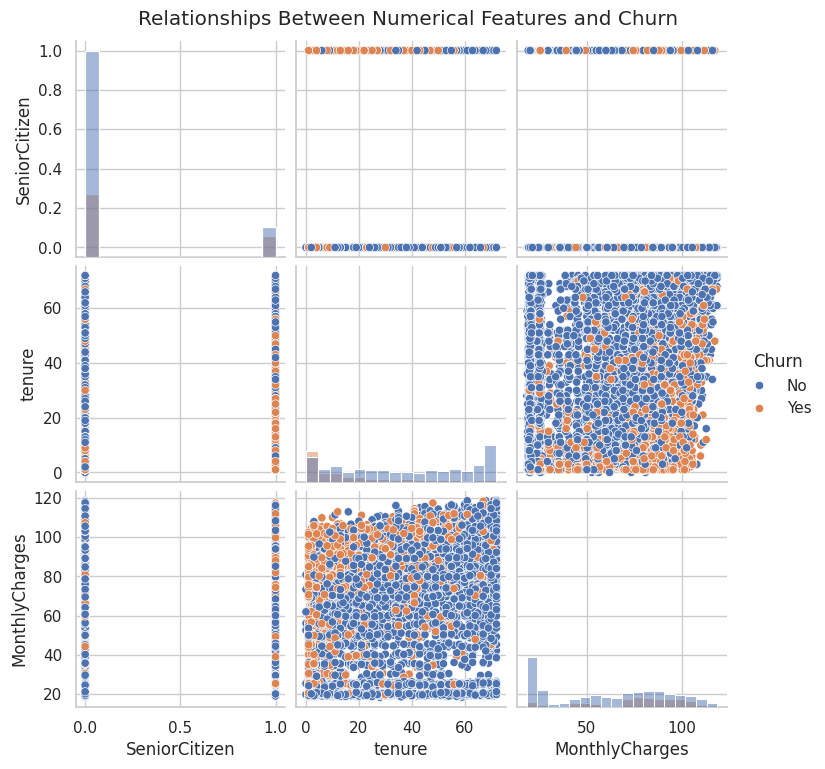

In [48]:
sns.pairplot(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "Churn"]],
    hue="Churn",
    diag_kind="hist"
)

plt.suptitle(
    "Relationships Between Numerical Features and Churn",
    y=1.02
)

plt.show()

## 5. Data Preprocessing

The preprocessing stage prepares the dataset for machine learning while preserving the information contained in the original data.

### 5.1 Total Charges Cleaning

The `TotalCharges` column was stored as a string/object data type despite representing a numerical monetary value. Eleven records contained blank values.

Investigation showed that all 11 records had a tenure of zero months, indicating that these customers were new customers with no accumulated charges. These blank values will therefore be interpreted as zero before converting the column to a numerical data type.

In [49]:
# Convert blank strings to NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(" ", np.nan),
    errors="coerce"
)

# Fill missing TotalCharges for new customers
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

Missing TotalCharges: 0
TotalCharges dtype: float64


In [51]:
# Remove columns created only for exploratory analysis
df_model = df.drop(
    columns=["TenureGroup", "ChurnBinary", "customerID"]
).copy()

print("Original shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Original shape: (7043, 23)
Modeling dataset shape: (7043, 20)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [53]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (5634, 19)
Test set: (1409, 19)

Training target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Test target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify feature types
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Numerical preprocessing
numeric_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully.")

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessing pipeline created successfully.


In [56]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 45)

Original test shape: (1409, 19)
Processed test shape: (1409, 45)


In [57]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(f"{i:02d}. {feature}")

Number of processed features: 45
01. num__SeniorCitizen
02. num__tenure
03. num__MonthlyCharges
04. num__TotalCharges
05. cat__gender_Female
06. cat__gender_Male
07. cat__Partner_No
08. cat__Partner_Yes
09. cat__Dependents_No
10. cat__Dependents_Yes
11. cat__PhoneService_No
12. cat__PhoneService_Yes
13. cat__MultipleLines_No
14. cat__MultipleLines_No phone service
15. cat__MultipleLines_Yes
16. cat__InternetService_DSL
17. cat__InternetService_Fiber optic
18. cat__InternetService_No
19. cat__OnlineSecurity_No
20. cat__OnlineSecurity_No internet service
21. cat__OnlineSecurity_Yes
22. cat__OnlineBackup_No
23. cat__OnlineBackup_No internet service
24. cat__OnlineBackup_Yes
25. cat__DeviceProtection_No
26. cat__DeviceProtection_No internet service
27. cat__DeviceProtection_Yes
28. cat__TechSupport_No
29. cat__TechSupport_No internet service
30. cat__TechSupport_Yes
31. cat__StreamingTV_No
32. cat__StreamingTV_No internet service
33. cat__StreamingTV_Yes
34. cat__StreamingMovies_No
35. cat

In [58]:
handle_unknown="ignore"

In [59]:
print(
    "Missing values in processed training data:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed test data:",
    np.isnan(X_test_processed).sum()
)

Missing values in processed training data: 0
Missing values in processed test data: 0


In [60]:
y_train_binary = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test_binary = y_test.map({
    "No": 0,
    "Yes": 1
})

print("Training target:")
print(y_train_binary.value_counts())

print("\nTest target:")
print(y_test_binary.value_counts())

Training target:
Churn
0    4139
1    1495
Name: count, dtype: int64

Test target:
Churn
0    1035
1     374
Name: count, dtype: int64


In [61]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train_binary
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [62]:
y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test_binary, y_pred)
precision = precision_score(y_test_binary, y_pred)
recall = recall_score(y_test_binary, y_pred)
f1 = f1_score(y_test_binary, y_pred)
roc_auc = roc_auc_score(y_test_binary, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040
ROC-AUC  : 0.8421


In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_binary,
    y_pred
)

print(cm)

[[926 109]
 [165 209]]


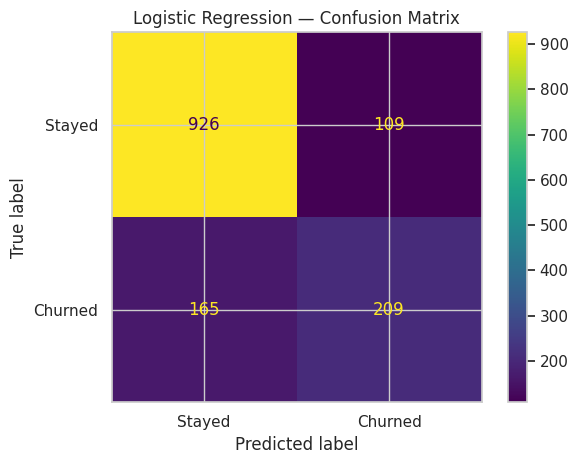

In [65]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [66]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 926
False Positives: 109
False Negatives: 165
True Positives : 209


In [67]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest.fit(
    X_train_processed,
    y_train_binary
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [68]:
rf_pred = random_forest.predict(X_test_processed)

rf_pred_proba = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [69]:
rf_accuracy = accuracy_score(y_test_binary, rf_pred)
rf_precision = precision_score(y_test_binary, rf_pred)
rf_recall = recall_score(y_test_binary, rf_pred)
rf_f1 = f1_score(y_test_binary, rf_pred)
rf_roc_auc = roc_auc_score(y_test_binary, rf_pred_proba)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1 Score : 0.5372
ROC-AUC  : 0.8227


In [70]:
rf_cm = confusion_matrix(
    y_test_binary,
    rf_pred
)

tn, fp, fn, tp = rf_cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 927
False Positives: 108
False Negatives: 197
True Positives : 177


In [71]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Random Forest,0.7835,0.6211,0.4733,0.5372,0.8227


In [72]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [74]:
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train_binary.value_counts()[0] /
    y_train_binary.value_counts()[1]
)

print(f"Scale positive weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train_binary
)

print("XGBoost trained successfully!")

Scale positive weight: 2.77
XGBoost trained successfully!


In [75]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_pred_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [76]:
xgb_accuracy = accuracy_score(y_test_binary, xgb_pred)
xgb_precision = precision_score(y_test_binary, xgb_pred)
xgb_recall = recall_score(y_test_binary, xgb_pred)
xgb_f1 = f1_score(y_test_binary, xgb_pred)
xgb_roc_auc = roc_auc_score(
    y_test_binary,
    xgb_pred_proba
)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.7544
Precision: 0.5258
Recall   : 0.7620
F1 Score : 0.6223
ROC-AUC  : 0.8409


In [77]:
xgb_cm = confusion_matrix(
    y_test_binary,
    xgb_pred
)

tn, fp, fn, tp = xgb_cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 778
False Positives: 257
False Negatives: 89
True Positives : 285


In [78]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Random Forest,0.7835,0.6211,0.4733,0.5372,0.8227
2,XGBoost,0.7544,0.5258,0.7620,0.6223,0.8409


In [79]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [80]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [81]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [82]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train_binary,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

print("Logistic Regression CV Results")

for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    print(
        f"{metric.replace('test_', '').upper():10s}: "
        f"{logistic_cv[metric].mean():.4f} "
        f"± {logistic_cv[metric].std():.4f}"
    )

Logistic Regression CV Results
ACCURACY  : 0.8021 ± 0.0118
PRECISION : 0.6529 ± 0.0262
RECALL    : 0.5431 ± 0.0411
F1        : 0.5923 ± 0.0299
ROC_AUC   : 0.8462 ± 0.0126


In [85]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):

    threshold_pred = (
        xgb_pred_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test_binary,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_binary,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_binary,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.4105,0.9385,0.5712
1,0.25,0.4313,0.9144,0.5861
2,0.30,0.4509,0.8957,0.5998
3,0.35,0.4708,0.8636,0.6094
4,0.40,0.4883,0.8369,0.6167
5,0.45,0.5101,0.8075,0.6253
6,0.50,0.5258,0.7620,0.6223
7,0.55,0.5397,0.7273,0.6196
8,0.60,0.5582,0.6791,0.6128
9,0.65,0.5869,0.6230,0.6044


In [84]:
xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train_binary,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

print("XGBoost CV Results")

for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    print(
        f"{metric.replace('test_', '').upper():10s}: "
        f"{xgb_cv[metric].mean():.4f} "
        f"± {xgb_cv[metric].std():.4f}"
    )

XGBoost CV Results
ACCURACY  : 0.7613 ± 0.0078
PRECISION : 0.5347 ± 0.0104
RECALL    : 0.7726 ± 0.0221
F1        : 0.6319 ± 0.0133
ROC_AUC   : 0.8434 ± 0.0107


In [86]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.2, 0.3]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [87]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

print("Starting XGBoost hyperparameter tuning...")

xgb_random_search.fit(
    X_train,
    y_train_binary
)

print("\nHyperparameter tuning completed!")

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Hyperparameter tuning completed!


In [88]:
print("Best F1 CV Score:")
print(round(xgb_random_search.best_score_, 4))

print("\nBest Parameters:")
for parameter, value in xgb_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Best F1 CV Score:
0.6375

Best Parameters:
model__subsample: 0.9
model__n_estimators: 200
model__min_child_weight: 3
model__max_depth: 5
model__learning_rate: 0.02
model__gamma: 0.1
model__colsample_bytree: 1.0


In [89]:
best_xgb = xgb_random_search.best_estimator_

tuned_xgb_pred = best_xgb.predict(X_test)
tuned_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(
    y_test_binary,
    tuned_xgb_pred
)

tuned_precision = precision_score(
    y_test_binary,
    tuned_xgb_pred
)

tuned_recall = recall_score(
    y_test_binary,
    tuned_xgb_pred
)

tuned_f1 = f1_score(
    y_test_binary,
    tuned_xgb_pred
)

tuned_roc_auc = roc_auc_score(
    y_test_binary,
    tuned_xgb_proba
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Accuracy : 0.7544
Precision: 0.5249
Recall   : 0.7888
F1 Score : 0.6303
ROC-AUC  : 0.8458


In [90]:
from sklearn.model_selection import cross_val_predict

xgb_oof_proba = cross_val_predict(
    xgb_random_search.best_estimator_,
    X_train,
    y_train_binary,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probabilities generated.")
print("Number of predictions:", len(xgb_oof_proba))

Out-of-fold probabilities generated.
Number of predictions: 5634


In [91]:
threshold_results_cv = []

for threshold in np.arange(0.20, 0.71, 0.05):

    threshold_pred = (
        xgb_oof_proba >= threshold
    ).astype(int)

    threshold_results_cv.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_train_binary,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train_binary,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_train_binary,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results_cv = pd.DataFrame(
    threshold_results_cv
)

threshold_results_cv.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.3927,0.9532,0.5562
1,0.25,0.4148,0.9264,0.5730
2,0.30,0.4356,0.9010,0.5873
3,0.35,0.4634,0.8816,0.6075
4,0.40,0.4848,0.8508,0.6176
5,0.45,0.5072,0.8207,0.6270
6,0.50,0.5347,0.7893,0.6375
7,0.55,0.5544,0.7398,0.6338
8,0.60,0.5901,0.6903,0.6363
9,0.65,0.6268,0.6268,0.6268


In [92]:
final_threshold = 0.50

final_test_proba = xgb_random_search.best_estimator_.predict_proba(
    X_test
)[:, 1]

final_test_pred = (
    final_test_proba >= final_threshold
).astype(int)

In [93]:
final_accuracy = accuracy_score(
    y_test_binary,
    final_test_pred
)

final_precision = precision_score(
    y_test_binary,
    final_test_pred
)

final_recall = recall_score(
    y_test_binary,
    final_test_pred
)

final_f1 = f1_score(
    y_test_binary,
    final_test_pred
)

final_roc_auc = roc_auc_score(
    y_test_binary,
    final_test_proba
)

print("FINAL TEST RESULTS")
print("------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

FINAL TEST RESULTS
------------------
Accuracy : 0.7544
Precision: 0.5249
Recall   : 0.7888
F1 Score : 0.6303
ROC-AUC  : 0.8458


In [94]:
final_cm = confusion_matrix(
    y_test_binary,
    final_test_pred
)

tn, fp, fn, tp = final_cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 768
False Positives: 267
False Negatives: 79
True Positives : 295


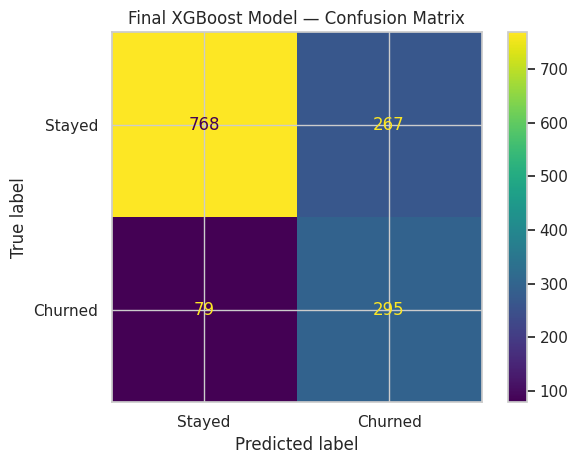

In [95]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Final XGBoost Model — Confusion Matrix")
plt.tight_layout()
plt.show()

In [96]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [97]:
final_preprocessor = best_xgb.named_steps["preprocessor"]
final_xgb_model = best_xgb.named_steps["model"]

print("Preprocessor:", type(final_preprocessor).__name__)
print("Model:", type(final_xgb_model).__name__)

Preprocessor: ColumnTransformer
Model: XGBClassifier


In [98]:
X_test_transformed = final_preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (1409, 45)


In [99]:
feature_names = final_preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies

In [100]:
explainer = shap.TreeExplainer(final_xgb_model)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 45)


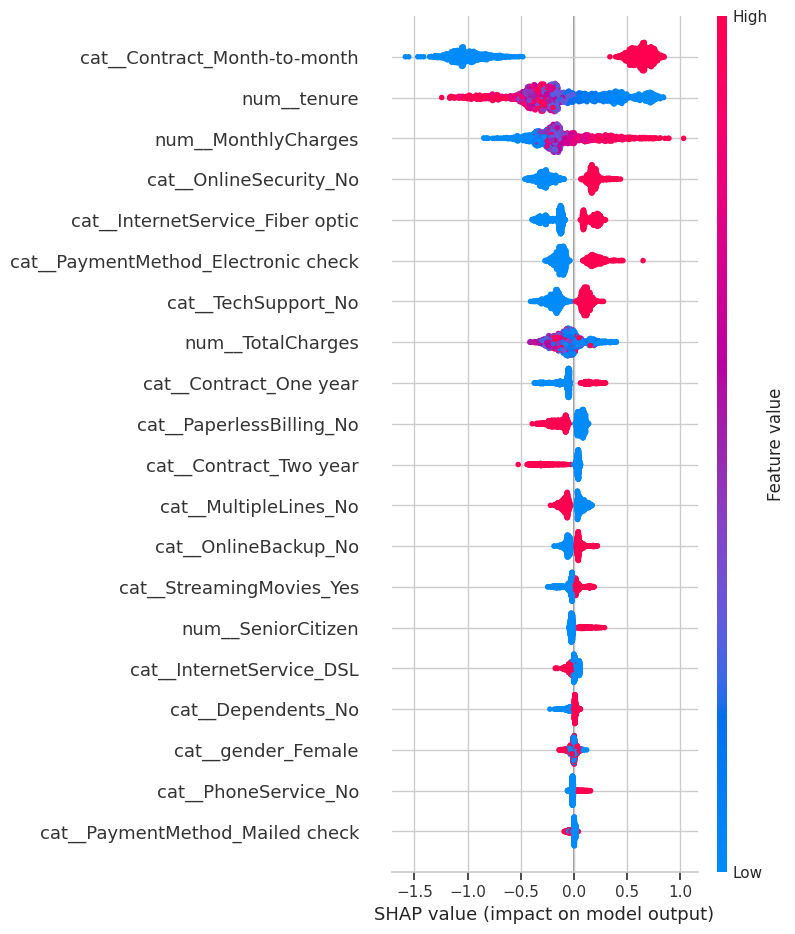

In [101]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

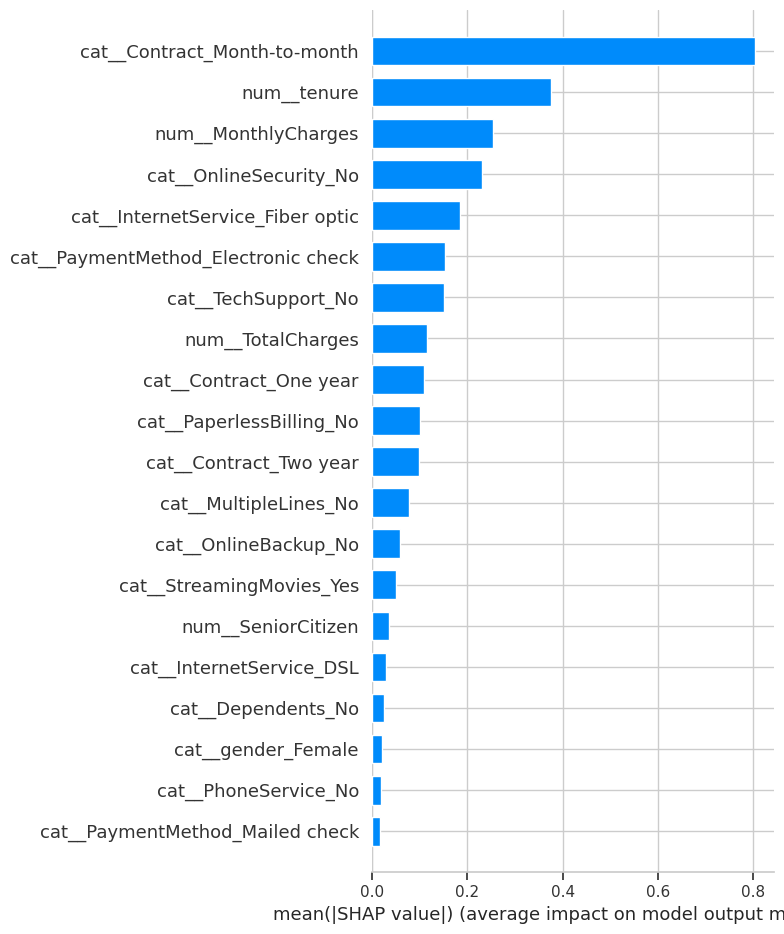

In [102]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

In [103]:
# Find the highest-risk customer in the test set
highest_risk_idx = np.argmax(final_test_proba)

print("Test-set position:", highest_risk_idx)
print("Churn probability:", round(final_test_proba[highest_risk_idx], 4))
print("Actual outcome:", y_test_binary.iloc[highest_risk_idx])

Test-set position: 1090
Churn probability: 0.9508
Actual outcome: 1


In [104]:
high_risk_customer = X_test.iloc[highest_risk_idx]

print(high_risk_customer)

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object


In [105]:
customer_shap = shap_values[highest_risk_idx]

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": customer_shap
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

customer_explanation.head(15)

,Feature,SHAP_Value,Absolute_SHAP
36,cat__Contract_Month-to-month,0.742085,0.742085
1,num__tenure,0.698348,0.698348
2,num__MonthlyCharges,0.258865,0.258865
16,cat__InternetService_Fiber optic,0.176042,0.176042
18,cat__OnlineSecurity_No,0.170775,0.170775
3,num__TotalCharges,0.161453,0.161453
27,cat__TechSupport_No,0.155202,0.155202
12,cat__MultipleLines_No,0.137108,0.137108
43,cat__PaymentMethod_Electronic check,0.133696,0.133696
39,cat__PaperlessBilling_No,0.087809,0.087809


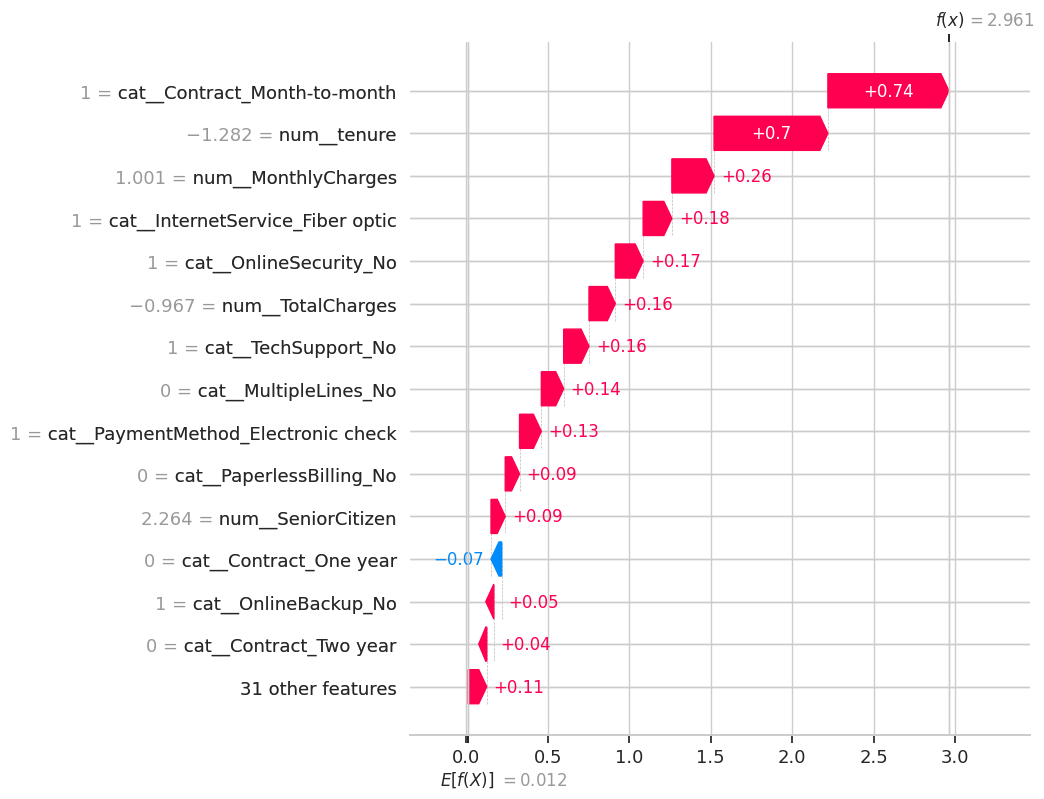

In [106]:
shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value,
        data=X_test_transformed[highest_risk_idx],
        feature_names=feature_names
    ),
    max_display=15
)

In [107]:
print(
    f"Customer churn probability: "
    f"{final_test_proba[highest_risk_idx] * 100:.2f}%"
)

print(
    "Predicted class:",
    "Churn" if final_test_pred[highest_risk_idx] == 1 else "Stay"
)

print(
    "Actual class:",
    "Churn" if y_test_binary.iloc[highest_risk_idx] == 1 else "Stay"
)

Customer churn probability: 95.08%
Predicted class: Churn
Actual class: Churn


In [108]:
import joblib

joblib.dump(
    xgb_random_search.best_estimator_,
    "/kaggle/working/customer_churn_xgb_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [109]:
import os

model_path = "/kaggle/working/customer_churn_xgb_pipeline.pkl"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print(
        "File size:",
        round(os.path.getsize(model_path) / (1024 * 1024), 2),
        "MB"
    )

Exists: True
File size: 0.49 MB
